### 随机梯度下降SGD

SGD的核心数学公式如下：

$$ w' = w - \eta*\nabla \mathcal{L}_w$$


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython import display
%matplotlib inline

$$y = x^2 + 10\sin(x)$$ 

In [2]:
# 模拟一个简单的损失函数
def lossFun(x):
    return x ** 2 + 10 * np.sin(x)


$$\frac{dy}{dx} = 2x + 10\cos(x)$$ 

In [3]:
# 损失函数的梯度
def gradient(x):
    return 2 * x + 10 * np.cos(x)


In [4]:
# 初始化参数和学习率
x = 5.0                          # 初始参数
lr = 0.01                        # 梯度下降步长（保守取值，保证迭代稳定不发散）
max_iter = 50                    # 最大迭代次数（保守取值，避免过度迭代）


In [5]:
# 绘制损失函数和参数更新过程
loss_history = []               # 记录每次迭代的损失函数值
x_history = []                  # 记录每次的x

for i in range(max_iter):
    # 获得当前点的梯度值
    grad = gradient(x)

    # 梯度下降更新参数
    x = x - lr * grad

    # 计算损失损失函数值,loss
    loss = lossFun(x)

    # 记录损失函数值与当前x
    loss_history.append(loss)
    x_history.append(x)

    # 如果函数值变化小于阈值(1e-5)，则跳出迭代
    if i > 1 and np.abs(loss_history[-1] - loss_history[-2]) < 1e-5:
        break


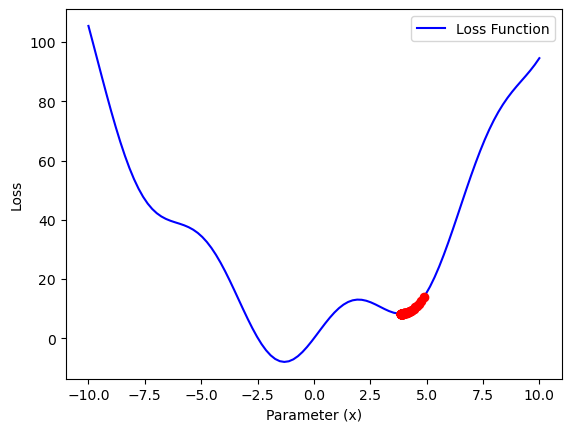

In [6]:
# 绘制损失函数曲线
x = np.linspace(-10, 10, 100)
loss_values = lossFun(x)

plt.plot(x, loss_values, 'b-', label='Loss Function')

# 绘制参数更新过程，风格ro
plt.plot(x_history, loss_history, 'ro')  # 绘制当前参数和损失值

plt.xlabel('Parameter (x)')
plt.ylabel('Loss')
plt.legend()
plt.show()

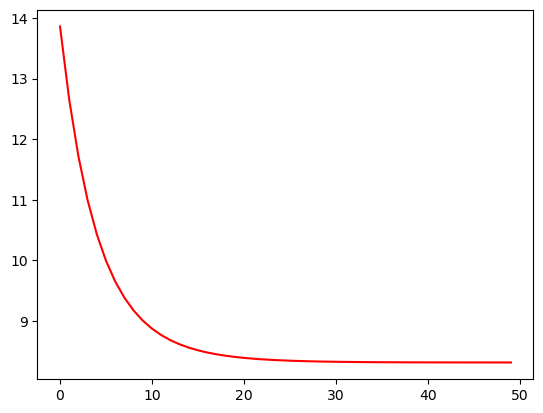

In [7]:
plt.plot(loss_history, color='red')
plt.show()

### 可视化随机梯度下降（SGD）的三维工作示例

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
%matplotlib inline

$$z = x^2 + y^2$$


In [9]:
# 模拟损失函数
def lossFun(x, y):
    return x ** 2 + y ** 2


$$\frac{\partial z}{\partial x} = 2x, \frac{\partial z}{\partial y} = 2y $$ 

In [10]:
# 模拟梯度计算
def gradient(x, y):
    return 2 * x, 2 * y


In [11]:
# 随机梯度下降
def sgd(lr, num_iters):
    loss_history = []
    xy_history = [] # 记录每次迭代的x,y值

    # 随机初始值x, y
    x = np.random.uniform(-10, 10)
    y = np.random.uniform(-10, 10)

    # 梯度下降
    for i in range(num_iters):
        # 1. 计算函数值
        loss = lossFun(x, y)

        # 2. 计算梯度值
        grad_x, grad_y = gradient(x, y)

        # 3. 更新参数
        x = x - lr * grad_x
        y = y - lr * grad_y

        # 记录函数值变化历史与x,y历史
        loss_history.append(loss)
        xy_history.append((x, y))

        # 如果函数值变化小于阈值，则跳出迭代
        if i > 1 and np.abs(loss_history[-1] - loss_history[-2]) < 1e-5:
            break

    return loss_history, xy_history


In [12]:
# 设置学习率和迭代次数
lr = 0.1                         # 保守步长：满足 0 < lr < 1，二次函数可稳定收敛
max_iter = 50


In [13]:
# 运行随机梯度下降
loss_rec, xy_rec = sgd(lr, max_iter)


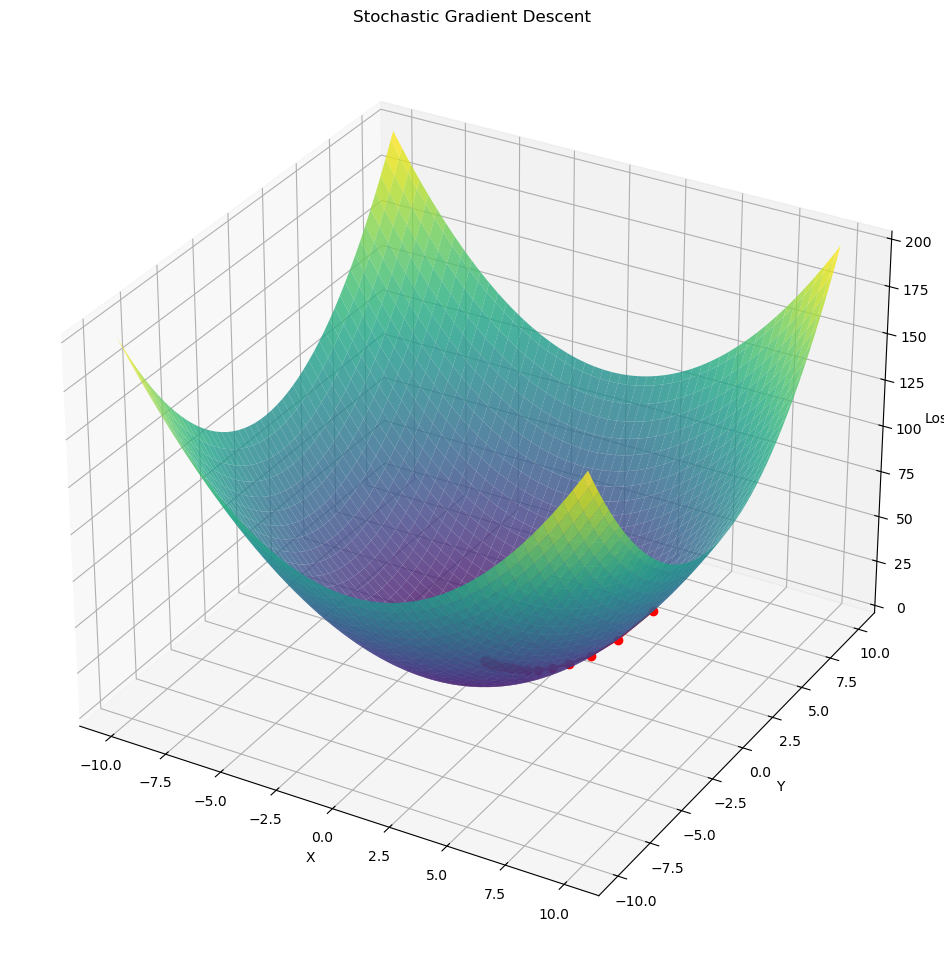

In [14]:
# 可视化损失函数
x = np.linspace(-10, 10, 100)
y = np.linspace(-10, 10, 100)
X, Y = np.meshgrid(x, y)
Z = lossFun(X, Y)

# 创建3D图形
fig = plt.figure(figsize=(15, 12))
ax = fig.add_subplot(111, projection='3d')

# 绘制损失函数表面
ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)

# 绘制随机梯度下降路径
sgd_x, sgd_y = zip(*xy_rec)
sgd_z = lossFun(np.array(sgd_x), np.array(sgd_y))
ax.plot(sgd_x, sgd_y, sgd_z, marker='o', color='r', linestyle='-')

# 设置图形属性
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Loss')
ax.set_title('Stochastic Gradient Descent')

plt.show()


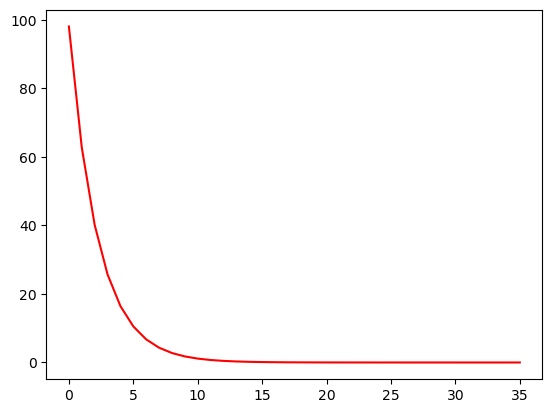

In [15]:
plt.plot(loss_rec, color='red')
plt.show()